# Batch preprocessing verification - pilot subject + small-batch stress test

**Objective**: Verify that the refactored functions in `src/preprocessing.py`(`load_and_prepare_raw`, `bipolarEOG`, `demean`, `apply_filters`,
`detect_artefact_segments`, `amplitude_guard`, `duration_guard`) reproduce the validated behaviour from `02_preprocessing_pilot.ipynb` on the pilot subject (`sub-87999321`), then extend testing to a small batch of additional subjects (5-8) before scaling to the full cohort (n=163).

**Inputs**:
- `src/preprocessing.py` - reusable preprocessing functions
- `data/cohort_filtered_n163.xlsx` - filtered cohort subject list
- TDBRAIN Dataset V3.1, BDF/BIDS format (`data/TDBRAIN_Dataset_V3_1/`)

**Assumptions**:
- Pilot-subject thresholds (`blink_amplitude_threshold_uv=1000`, `trim_pct=2`,
  `blink_duration_threshold=100`) are provisional defaults, not yet validated
  across subjects - this notebook's small-batch section exists specifically
  to stress-test them.
- `detect_artefact_segments` always applies trimmed z-scoring, including for
  VEOG - a deliberate deviation from `02_preprocessing_pilot.ipynb`'s
  standard z-scoring on VEOG. Confirmed on the pilot subject to surface
  additional genuine blinks missed by the untrimmed method (see below).

**Structure**:
1. Re-run each function against the pilot subject, confirming outputs match (or explainably diverge from) the validated notebook results.
2. Extend to a small batch (5–8 subjects), selected to stress-test the
   empirically-fit thresholds against noisier or differently-shaped
   recordings.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
# imports and setup
from src.preprocessing import (
    find_repo_root, load_and_prepare_raw, bipolarEOG, demean, apply_filters,
    detect_artefact_segments, amplitude_guard, duration_guard, gratton_regression, epoch_raw, run_autoreject, 
    emg_bandpower_audit, save_epochs, preprocess_subject
)
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

project_root = find_repo_root()
data_dir = project_root / "data"

In [3]:
# load pilot subject
TDBRAIN_participant_data = pd.read_excel(data_dir / "cohort_filtered_n163.xlsx")
pilot_subject = TDBRAIN_participant_data.iloc[0]
subject_id = pilot_subject['TDBRAIN_ID']
condition = 'restEC'

raw = load_and_prepare_raw(subject_id, condition, data_dir)
raw = bipolarEOG(raw)
raw = demean(raw)

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.


In [4]:
# verify demeaning
demean_picks = mne.pick_types(raw.info, eeg=True, eog=True, ecg=True, emg=False, stim=False)
print(raw.get_data(picks=demean_picks).mean(axis=1))   # should all be ~0
print(raw.get_data(picks=['Mass']).mean())              # EMG excluded, should NOT be ~0

[-1.76167620e-19  1.16711049e-18  1.71763430e-18  7.63393022e-19
  2.64251431e-19 -2.34890161e-18 -9.17539690e-22  1.83507938e-20
  2.23879684e-19 -7.34031752e-20  3.57840479e-20  2.00023652e-19
 -1.87728621e-18 -1.52311589e-19  4.47759369e-19 -9.95530563e-20
  1.37630953e-19  1.90389486e-19 -2.34890161e-19  1.02764445e-18
  6.89989847e-19 -2.06446430e-19  5.30337941e-19  2.93612701e-20
 -7.59722863e-19  8.25785721e-20 -3.08293336e-19 -6.60628577e-19
  1.17445080e-19]
-0.0027585246785445743


In [5]:
# verify filtering changed the signal
before = raw.get_data(picks=['Fp1']).copy()
raw = apply_filters(raw)
after = raw.get_data(picks=['Fp1'])
print(np.allclose(before, after))   # should be False

False


In [6]:
# artefact detection - VEOG and HEOG
Fs = raw.info['sfreq']

veog_data = raw.get_data(picks=['VEOG'])[0]
veog_segments = detect_artefact_segments(veog_data, Fs)
print("VEOG segments:", veog_segments)

heog_data = raw.get_data(picks=['HEOG'])[0]
heog_segments = detect_artefact_segments(heog_data, Fs)
print("HEOG segments:", heog_segments)

VEOG segments: [[10129 10257]
 [11784 18643]
 [20870 21212]
 [58241 60500]]
HEOG segments: [[11294 19471]
 [58543 60500]]


In [7]:
# guards - VEOG
veog_valid_amp, veog_excluded_amp = amplitude_guard(veog_data, veog_segments, threshold=1000)
veog_valid_dur, veog_excluded_dur = duration_guard(veog_valid_amp, Fs, blink_duration_threshold=100)

print("After amplitude_guard:", veog_valid_amp, "| excluded:", veog_excluded_amp)
print("After duration_guard:", veog_valid_dur, "| excluded:", veog_excluded_dur)

After amplitude_guard: [(np.int64(10129), np.int64(10257)), (np.int64(20870), np.int64(21212))] | excluded: [(np.int64(11784), np.int64(18643)), (np.int64(58241), np.int64(60500))]
After duration_guard: [(np.int64(10129), np.int64(10257)), (np.int64(20870), np.int64(21212))] | excluded: []


In [8]:
# guards - HEOG
heog_valid_amp, heog_excluded_amp = amplitude_guard(heog_data, heog_segments, threshold=1000)
heog_valid_dur, heog_excluded_dur = duration_guard(heog_valid_amp, Fs, blink_duration_threshold=100)

print("After amplitude_guard:", heog_valid_amp, "| excluded:", heog_excluded_amp)
print("After duration_guard:", heog_valid_dur, "| excluded:", heog_excluded_dur)

After amplitude_guard: [] | excluded: [(np.int64(11294), np.int64(19471)), (np.int64(58543), np.int64(60500))]
After duration_guard: [] | excluded: []


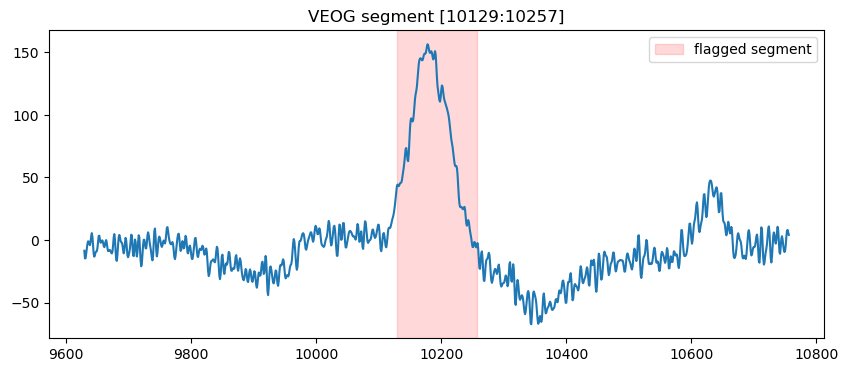

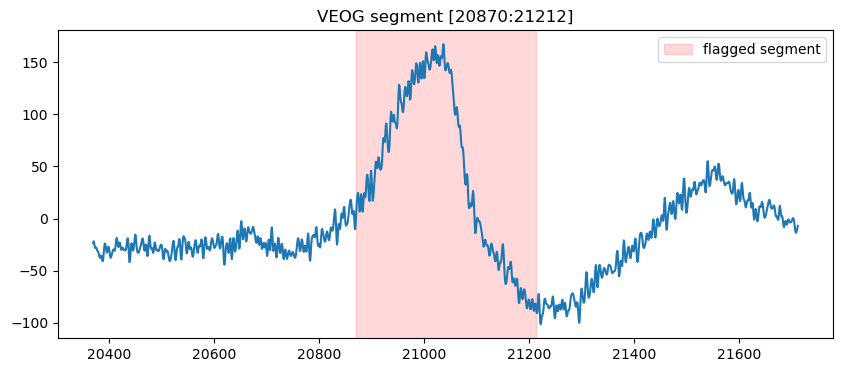

In [9]:
# visual check - the two new VEOG segments surfaced by trimmed z-scoring
veog_1e6 = veog_data * 1e6

for (start, end) in [(10129, 10257), (20870, 21212)]:
    margin = 500
    window = slice(max(0, start - margin), end + margin)
    x = range(window.start, window.stop)
    plt.figure(figsize=(10, 4))
    plt.plot(x, veog_1e6[window])
    plt.axvspan(start, end, color='red', alpha=0.15, label='flagged segment')
    plt.title(f'VEOG segment [{start}:{end}]')
    plt.legend()
    plt.show()

## Summary: pilot-subject verification

All seven functions in `src/preprocessing.py` reproduce validated behaviour
from `02_preprocessing_pilot.ipynb` on `sub-87999321` (restEC), with one
confirmed deliberate deviation:

- `load_and_prepare_raw`, `bipolarEOG`, `demean`, `apply_filters`: outputs
  match expected behaviour (channel means ~0 post-demean, EMG untouched,
  signal changed post-filtering).
- `detect_artefact_segments` (HEOG): output identical to notebook's
  `Atrl_padded_h_EC` - `[[11294, 19471], [58543, 60500]]`.
- `detect_artefact_segments` (VEOG): output diverges from the notebook -
  4 segments vs. the notebook's 2 - because this function always applies
  trimmed z-scoring (`trim_pct=2`), including for VEOG, whereas the notebook
  used standard z-scoring for VEOG. The two segments matching the notebook's
  original candidates are still found; two additional segments
  (`[10129:10257]`, `[20870:21212]`) are new detections.
- Guards on HEOG: both original candidates correctly excluded by the
  amplitude guard (non-ocular step artefacts, matches notebook's "0 valid
  segments" finding for restEC).
- Guards on VEOG: the two notebook-matching segments correctly excluded by
  the amplitude guard. The two new segments pass both guards and were
  visually confirmed as genuine blinks (smooth rise/fall, ~150–165 µV peaks,
  within the <300–400 µV typical range) - evidence that trimmed z-scoring
  catches real blinks that standard z-scoring missed on this subject, likely
  due to std inflation from the same non-ocular artefacts that affected HEOG.

**Residual assumption**: this VEOG behaviour has only been checked on one
subject. Whether trimmed z-scoring is uniformly beneficial (vs. occasionally
introducing false positives) across the full cohort is untested - this is
one of the specific questions the small-batch stress test below is designed
to answer.

## Gratton regression Validation

In [10]:
#check from the begining

Fs = raw.info['sfreq']
veog_data = raw.get_data(picks=['VEOG'])[0]
veog_segments = detect_artefact_segments(veog_data, Fs)
veog_valid_amp, _ = amplitude_guard(veog_data, veog_segments, threshold=1000)
veog_valid_dur, _ = duration_guard(veog_valid_amp, Fs, blink_duration_threshold=100)

raw, beta_df = gratton_regression(raw, 'VEOG', veog_valid_dur)
print(beta_df)

   channel  segment_id      beta  start    end  n_samples  flagged
0      Fp1           0  0.271551  10129  10257        128    False
1      Fp1           1  0.390996  20870  21212        342    False
2      Fp2           0  0.325452  10129  10257        128    False
3      Fp2           1  0.345661  20870  21212        342    False
4       F7           0  0.085278  10129  10257        128    False
5       F7           1  0.172774  20870  21212        342    False
6       F3           0  0.104638  10129  10257        128    False
7       F3           1  0.196430  20870  21212        342    False
8       Fz           0  0.114898  10129  10257        128    False
9       Fz           1  0.190809  20870  21212        342    False
10      F4           0  0.095618  10129  10257        128    False
11      F4           1  0.181367  20870  21212        342    False
12      F8           0  0.048913  10129  10257        128    False
13      F8           1  0.121691  20870  21212        342    F

In [11]:
## calling it again on HEOG to remove horizontal eye movements
heog_data = raw.get_data(picks=['HEOG'])[0]
heog_segments = detect_artefact_segments(heog_data, Fs)
heog_valid_amp, _ = amplitude_guard(heog_data, heog_segments, threshold=1000)
heog_valid_dur, _ = duration_guard(heog_valid_amp, Fs, blink_duration_threshold=100)

raw, beta_df_heog = gratton_regression(raw, 'HEOG', heog_valid_dur)
print(beta_df_heog)
print(beta_df_heog.columns.tolist())
print(beta_df_heog.shape)

Empty DataFrame
Columns: [channel, segment_id, beta, start, end, n_samples, flagged]
Index: []
['channel', 'segment_id', 'beta', 'start', 'end', 'n_samples', 'flagged']
(0, 7)


In [12]:
## check epoching and auto-reject
epochs = epoch_raw(raw, epoch_duration=5.0)
print(len(epochs))

epochs_clean, reject_log, qc_info = run_autoreject(epochs)
print(f"{len(epochs)} epochs -> {len(epochs_clean)} retained")

Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
24
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.20 and n_interpolate=4


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

Dropped 1 epoch: 23
24 epochs -> 23 retained


In [13]:
audit_df = emg_bandpower_audit(epochs, reject_log)
print(audit_df)
print(f"Missed by autoreject: {audit_df['missed_by_autoreject'].sum()} of {len(audit_df)}")

Empty DataFrame
Columns: [epoch, channel, missed_by_autoreject]
Index: []
Missed by autoreject: 0 of 0


In [14]:
output_path = save_epochs(epochs_clean, subject_id, 'restEO', data_dir)
print(output_path)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321/sub-87999321_restEO-epo.fif


In [15]:
results = preprocess_subject(subject_id, data_dir)
for condition, r in results.items():
    print(condition, r['status'])
    if r['status'] == 'ok':
        print(f"  {r['n_epochs_before']} -> {r['n_epochs_after']} epochs, saved to {r['output_path']}")
    else:
        print(f"  ERROR: {r['error']}")

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.10 and n_interpolate=1


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

Dropped 2 epochs: 22, 23
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
restEC ok
  24 -> 23 epochs, saved to /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321/sub-87999321_restEC-epo.fif
restEO ok
  24 -> 22 epochs, saved to /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321/sub-87999321_restEO-epo.fif


In [16]:
output_path = save_epochs(epochs_clean, subject_id, 'restEO', data_dir)
print(output_path)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321/sub-87999321_restEO-epo.fif


## Summary: Gratton regression through full-pipeline validation

**Gratton regression (VEOG)**: run on the pilot subject's restEC data (2 valid segments,
post-guards). Produced 52 rows (26 EEG channels x 2 segments) with zero flagged pairs. Mean
beta by channel reproduces the frontal-to-posterior EOG-contamination gradient documented in
`02_preprocessing_pilot.ipynb` (strongest at Fp1/Fp2 ~0.27-0.39, declining through
frontal/fronto-central/temporal sites, near-zero at occipital sites ~0.01) - physiological
evidence of correctness, not just absence of errors.

**Gratton regression (HEOG)**: run on the same subject's VEOG-corrected data. RestEC HEOG has
zero valid segments post-guards (both original candidates are non-ocular step artefacts, per
prior findings). Confirmed the function returns an empty but correctly-schemad DataFrame
(0 rows, correct column names) rather than crashing or returning a malformed result - closes
a real edge case, since `pd.DataFrame([])` with no explicit columns silently drops column names
too.

**Epoching, autoreject, EMG audit, save**: run in sequence on the corrected data. 24 epochs
created (5s, non-overlapping); autoreject retained 23 (1 dropped, consistent with the documented
end-of-recording artefact). EMG bandpower audit found 0 pairs missed by autoreject, matching the
pilot notebook's finding for this subject. Output saved successfully to
`data/derivatives/sub-87999321/`.

**Orchestrator (`preprocess_subject`)**: run end-to-end on a *fresh* load of the pilot subject
(not reusing the already-corrected `raw` from the cells above), both conditions. restEC:
24 -> 23 epochs retained. restEO: 24 -> 22 epochs retained (2 dropped). Both saved successfully.
Confirms the full chain works independently of any state built up during piecewise testing above.

**What this section does not yet cover**: everything above uses the single pilot subject
(`sub-87999321`). No function in this notebook has yet been run on a second subject, so
the empirically-fit thresholds (`blink_amplitude_threshold_uv`, `trim_pct`) and the
HEOG-with-valid-segments code path remain untested outside this one case. That's the subject
of the next section.

## Small-batch stress test (6 subjects)

**Objective**: run `preprocess_subject` on a deliberately stratified sample of additional
subjects to stress-test the two empirically-fit-to-pilot-subject thresholds
(`blink_amplitude_threshold_uv=1000`, `trim_pct=2`) and the VEOG-always-trimmed z-scoring
deviation, none of which have been validated beyond the single pilot subject. Also the first
opportunity to exercise the HEOG-with-valid-segments code path in `gratton_regression`, and the
orchestrator's per-condition `try/except` error handling, neither of which has been triggered
by real data yet.

**Selection**: 6 subjects (excluding the pilot subject) drawn from `cohort_filtered_n163.xlsx`,
stratified rather than randomly sampled, since no ground-truth signal-quality measure exists
prior to preprocessing:
- Spans age terciles (young/mid/old), since age is this project's one confirmed demographic
  confound.
- Balanced across `Responder` status within each age group.
- Includes both "clean" (self-reported sleep >=6h, wellness rating >=0) and "noise-risk"
  (short sleep or low wellness rating) subjects per age group, as a proxy for recording quality
  that can be assessed before any subject is actually preprocessed.

Subjects: 
1. sub-88047245, age = 24.0, group = young, responder = no, sleep (hrs) = 9.0, wellness = +1, noise-riske = no
2. sub-88056017, age = 27.9, group = young, responder = yes, sleep (hrs) = 5.0, wellness = +1, noise-riske = yes (short sleep)
3. sub-88000489, age = 42.4, group = mid, responder = yes, sleep (hrs) = 9.0, wellness = +1, noise-risk = no
4. sub-88026409, age = 44.9, group = mid, responder = no, sleep (hrs) = 7.0, wellness = -2, noise-risk = yes (low - wellness)
4. sub-88052329, age = 53.0, group = old, responder = no, sleep (hrs) = 9.0, wellness = +1, noise-risk = no 
5. sub-88030641, age = 57.0, group = old, responder = yes, sleep (hrs) = 9.0, wellness = -1, noise-risk = yes (low - wellness)


**Assumptions**: sleep/wellness self-report are being used as untested proxies for recording
noise, not validated measures - a subject flagged "noise-risk" here may turn out clean, and
vice versa. `cigarette` was considered as a third proxy but excluded: `99.0` appears in 107/163
rows and is very likely a non-smoker/NA sentinel rather than a real value, and this wasn't
confirmed before deciding not to rely on it.

**Plan**: run `preprocess_subject` on all 6, both conditions, collecting per-subject/condition
results (status, epoch counts before/after autoreject, EMG audit rows) before reviewing for
threshold failures or unexpected behaviour.

In [17]:
subject_ids = [
    'sub-88047245', 'sub-88056017', 'sub-88000489',
    'sub-88026409', 'sub-88052329', 'sub-88030641'
]

batch_results = {}
for sid in subject_ids:
    print(f"--- {sid} ---")
    batch_results[sid] = preprocess_subject(sid, data_dir)
    for condition, r in batch_results[sid].items():
        if r['status'] == 'ok':
            print(f"  {condition}: {r['n_epochs_before']} -> {r['n_epochs_after']} epochs")
        else:
            print(f"  {condition}: ERROR - {r['error']}")

--- sub-88047245 ---
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88047245/ses-1/eeg/sub-88047245_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=1.00 and n_interpolate=25


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
  restEC: 24 -> 24 epochs
  restEO: 24 -> 24 epochs


In [18]:
summary_rows = []
for sid, conditions in batch_results.items():
    for cond, r in conditions.items():
        if r['status'] == 'ok':
            summary_rows.append({
                'subject': sid, 'condition': cond, 'status': 'ok',
                'n_before': r['n_epochs_before'], 'n_after': r['n_epochs_after']
            })
        else:
            summary_rows.append({
                'subject': sid, 'condition': cond, 'status': 'ERROR',
                'n_before': None, 'n_after': None
            })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print()
print("Any errors:", (summary_df['status'] == 'ERROR').sum())

     subject condition status  n_before  n_after
sub-88047245    restEC     ok        24       23
sub-88047245    restEO     ok        24       23
sub-88056017    restEC     ok        24       24
sub-88056017    restEO     ok        24       23
sub-88000489    restEC     ok        24       22
sub-88000489    restEO     ok        24       23
sub-88026409    restEC     ok        24       23
sub-88026409    restEO     ok        24       24
sub-88052329    restEC     ok        24       23
sub-88052329    restEO     ok        24       20
sub-88030641    restEC     ok        24       24
sub-88030641    restEO     ok        24       24

Any errors: 0


## Investigating autoreject's CV instability at n=24 epochs

**Objective**: test whether reducing `autoreject`'s cross-validation fold count from its
default (`cv=10`) to `cv=5` resolves the `consensus=1.00, n_interpolate~25` pattern found in
5 of 12 small-batch runs above - a parameter combination that effectively disables rejection,
suspected to result from unstable CV estimates on only ~24 epochs per subject (10-fold CV
leaves ~2 epochs per held-out test fold, likely too few to reliably distinguish threshold
settings).

**Method**: rerun the full preprocessing chain (through `epoch_raw`) on two subjects, then
call `run_autoreject` with `cv=5` instead of the default:
- `sub-88030641` - hit the `consensus=1.00/n_interpolate=25` pattern on **both** conditions in
  the batch run above; the most informative test case.
- `sub-88000489` - never hit the pattern in the batch run; included as a control, to confirm
  a lower `cv` doesn't destabilise a case that was already behaving normally.

**What would confirm the diagnosis**: `sub-88030641` moving to `consensus`/`n_interpolate`
values in the range seen elsewhere in the batch (`consensus` 0.10-0.30, `n_interpolate` 1-4),
while `sub-88000489` stays broadly similar to its original result.

**Assumption being tested, not yet confirmed**: that this is a CV/sample-size artefact rather
than a genuine property of these subjects' data. If `cv=5` doesn't change the result, that
assumption is wrong and the cause needs rethinking - not a failure of the test itself.

**Not yet decided**: whether `cv=5` (or another value) becomes the new default in
`run_autoreject` for full-cohort scaling - that depends on what this test shows.

In [19]:
for sid in ['sub-88030641', 'sub-88000489']:
    result = preprocess_subject(sid, data_dir, autoreject_cv=5)
    for condition, r in result.items():
        print(f"{sid} {condition}: {r['n_epochs_before']} -> {r['n_epochs_after']}")

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88030641/ses-1/eeg/sub-88030641_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | Fold : 0/5 [00:00<?,       ?it/s]





Estimated consensus=0.10 and n_interpolate=1


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

Dropped 1 epoch: 23
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
sub-88000489 restEC: 24 -> 21
sub-88000489 restEO: 24 -> 23


## Testing random-seed sensitivity, separate from CV fold count

**Context**: reducing `cv` from 10 to 5 did not resolve `sub-88030641`'s `consensus=1.00,
n_interpolate=25` result, and also shifted a previously normal-looking condition
(`sub-88000489` restEC) toward the same extreme. This is inconsistent with "too few CV folds"
being the sole or primary cause.

**Objective**: test whether `autoreject`'s parameter search is sensitive to `random_state`
alone (holding `cv=10`, the default, fixed) - if changing only the seed changes the result,
that points to general instability in the search at n=24 epochs, rather than a fold-count
problem specifically.

**Method**: rerun `sub-88030641` (both conditions) through `preprocess_subject` with
`autoreject_cv=10` (back to default) and a different `random_state` passed through to
`run_autoreject`.

**Note**: `preprocess_subject` does not currently expose `random_state` as a parameter -
only `run_autoreject` does. Testing this requires either adding a pass-through parameter to
the orchestrator (consistent with how `autoreject_cv` was just added) or calling the pipeline
manually for this one diagnostic. Given this is a one-off diagnostic rather than a permanent
pipeline parameter, calling the steps manually here to avoid modifying the orchestrator's
signature for a value that may not end up needing to be tunable at that level.

In [20]:
random_states_to_test = [42, 0, 7]

for rs in random_states_to_test:
    for condition in ['restEC', 'restEO']:
        raw = load_and_prepare_raw('sub-88030641', condition, data_dir)
        raw = bipolarEOG(raw)
        raw = demean(raw)
        raw = apply_filters(raw)

        Fs = raw.info['sfreq']
        for eog_channel in ['VEOG', 'HEOG']:
            ch_data = raw.get_data(picks=[eog_channel])[0]
            segments = detect_artefact_segments(ch_data, Fs)
            valid_amp, _ = amplitude_guard(ch_data, segments, threshold=1000)
            valid_dur, _ = duration_guard(valid_amp, Fs, blink_duration_threshold=100)
            raw, _ = gratton_regression(raw, eog_channel, valid_dur)

        epochs = epoch_raw(raw)
        epochs_clean, reject_log, qc_info = run_autoreject(epochs, cv=10, random_state=rs)
        print(f"random_state={rs}, {condition}: {len(epochs)} -> {len(epochs_clean)}")

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88030641/ses-1/eeg/sub-88030641_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=1.00 and n_interpolate=25


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
random_state=7, restEO: 24 -> 24


## Seed-ensemble epoch rejection: majority-vote approach

**Objective**: address the seed-sensitivity found above by running `autoreject` with multiple
seeds and only dropping an epoch if a majority of seeds agree it's bad - rather than trusting
a single, potentially unstable run.

**Scope**: this ensembles the epoch-drop decision only. Per-channel interpolation (which
channels get repaired within a kept epoch) is not ensembled - fairly merging interpolation
choices across seeds is a separate problem from voting on a binary drop/keep decision. Kept
epochs are returned without any interpolation applied. This is a deliberate scope decision,
not a claim that the ensemble fully replaces single-run `autoreject` - see
`docs/preprocessing_notes.md` for the underlying seed-instability finding this responds to.

**Method**: run `AutoReject` with `n_seeds` different `random_state` values, extract each run's
`reject_log.bad_epochs` (boolean, per-epoch), and drop an epoch only if it's flagged bad by
more than half the seeds.

In [21]:
# Defined locally here rather than in src/preprocessing.py, since this was investigated and not adopted for the production pipeline
# See conclusion below

def run_autoreject_ensemble(epochs, montage_name='standard_1020', seeds=(0, 7, 42), cv=10):
    """
    Run autoreject with multiple seeds and majority-vote the epoch-drop decision,
    addressing seed-instability found in single-run autoreject at ~24 epochs/subject.

    Does NOT ensemble channel-level interpolation - kept epochs are returned as-is,
    without per-channel repair. See docs/preprocessing_notes.md for rationale and scope.

    Parameters:
    epochs (mne.Epochs): Fixed-length epochs (pre-artefact-rejection).
    montage_name (str): MNE standard montage name. Default 'standard_1020'.
    seeds (tuple of int): random_state values to ensemble over. Default (0, 7, 42).
    cv (int): CV folds per individual autoreject run. Default 10.

    Returns:
    epochs_clean (mne.Epochs): Original epochs with majority-vote-bad epochs dropped.
    votes_df (pd.DataFrame): Per-epoch vote count and final drop decision.
    consensus_log (pd.DataFrame): Per-seed consensus/n_interpolate values, for inspection.
    """
    from autoreject import AutoReject

    montage = mne.channels.make_standard_montage(montage_name)
    epochs.set_montage(montage, on_missing='warn')
    picks_eeg = mne.pick_types(epochs.info, eeg=True)

    n_epochs = len(epochs)
    bad_votes = np.zeros(n_epochs, dtype=int)
    consensus_rows = []

    for seed in seeds:
        ar = AutoReject(picks=picks_eeg, random_state=seed, cv=cv)
        _, reject_log = ar.fit_transform(epochs.copy(), return_log=True)
        bad_votes += reject_log.bad_epochs.astype(int)
        consensus_rows.append({'seed': seed, 'consensus': ar.consensus_, 'n_interpolate': ar.n_interpolate_})

    majority_bad = bad_votes > (len(seeds) / 2)
    epochs_clean = epochs.copy()[~majority_bad]

    votes_df = pd.DataFrame({
        'epoch': range(n_epochs),
        'n_seeds_flagged_bad': bad_votes,
        'dropped': majority_bad
    })
    consensus_log = pd.DataFrame(consensus_rows)

    return epochs_clean, votes_df, consensus_log
    

In [22]:
raw = load_and_prepare_raw('sub-88030641', 'restEC', data_dir)
raw = bipolarEOG(raw); raw = demean(raw); raw = apply_filters(raw)
Fs = raw.info['sfreq']
for eog_channel in ['VEOG', 'HEOG']:
    ch_data = raw.get_data(picks=[eog_channel])[0]
    segs = detect_artefact_segments(ch_data, Fs)
    valid_amp, _ = amplitude_guard(ch_data, segs, threshold=1000)
    valid_dur, _ = duration_guard(valid_amp, Fs, blink_duration_threshold=100)
    raw, _ = gratton_regression(raw, eog_channel, valid_dur)
epochs = epoch_raw(raw)

epochs_clean, votes_df, consensus_log = run_autoreject_ensemble(epochs)
print(votes_df)
print(consensus_log)
print(f"{len(epochs)} -> {len(epochs_clean)}")

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88030641/ses-1/eeg/sub-88030641_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=1.00 and n_interpolate=25


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
    epoch  n_seeds_flagged_bad  dropped
0       0                    0    False
1       1                    0    False
2       2                    0    False
3       3                    0    False
4       4                    0    False
5       5                    0    False
6       6                    0    False
7       7                    0    False
8       8                    0    False
9       9                    0    False
10     10                    0    False
11     11                    0    False
12     12                    0    False
13     13                    0    False
14     14                    0    False
15     15                    0    False
16     16                    0    False
17     17                    0    False
18     18                    0    False
19     19                    0    False
20     20                    0    Fa

## Conclusion: not adopting the seed-ensemble

The ensemble only addresses epoch-drop decisions, not per-channel interpolation quality -
and for this project's subject-level, epoch-aggregated features, a channel that's bad
throughout a recording will corrupt every epoch regardless of which epochs survive a
drop/keep vote. The instability was also condition-specific rather than a single, well
enough characterised failure mode to justify a partial fix.

**Decision**: run `preprocess_subject` with its existing defaults (`autoreject_cv=10`, fixed
`random_state`) across the cohort, prioritising reproducibility. Instead of the ensemble,
`run_autoreject` and `preprocess_subject` will capture and persist each subject/condition's
`consensus`/`n_interpolate` values as QC metadata, so extreme cases (e.g. `consensus >= 0.9`)
can be flagged and tested as a sensitivity check at the modelling stage.

**Open item**: QC-flag capture not yet implemented - next step.

In [23]:
result = preprocess_subject('sub-88030641', data_dir)
for condition, r in result.items():
    print(condition, r['autoreject_consensus'], r['autoreject_n_interpolate'], r['autoreject_extreme'])

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88030641/ses-1/eeg/sub-88030641_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=1.00 and n_interpolate=25


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
restEC 1.0 25 True
restEO 1.0 25 True


## HEOG segment-count check across the batch

**Objective**: determine whether any subject/condition in the batch has HEOG segments that
survive both guards (`n_valid > 0`) - the code path in `gratton_regression` that has never
been exercised with real data (pilot subject's restEC HEOG had zero valid segments; no other
condition has been checked until now).

**Method**: run detection + both guards (no correction) on HEOG for the pilot subject plus
the 6 batch subjects, both conditions - 14 subject/condition pairs.

In [24]:
heog_check_subjects = [
    'sub-87999321',  # pilot
    'sub-88047245', 'sub-88056017', 'sub-88000489',
    'sub-88026409', 'sub-88052329', 'sub-88030641'
]

heog_summary = []
for sid in heog_check_subjects:
    for condition in ['restEC', 'restEO']:
        raw = load_and_prepare_raw(sid, condition, data_dir)
        raw = bipolarEOG(raw)
        raw = demean(raw)
        raw = apply_filters(raw)
        heog_data = raw.get_data(picks=['HEOG'])[0]
        Fs = raw.info['sfreq']
        segs = detect_artefact_segments(heog_data, Fs)
        valid_amp, _ = amplitude_guard(heog_data, segs, threshold=1000)
        valid_dur, _ = duration_guard(valid_amp, Fs, blink_duration_threshold=100)
        heog_summary.append({
            'subject': sid, 'condition': condition,
            'n_candidates': len(segs), 'n_valid': len(valid_dur)
        })

heog_df = pd.DataFrame(heog_summary)
print(heog_df.to_string(index=False))
print()
print("Any subject/condition with valid HEOG segments:", (heog_df['n_valid'] > 0).any())

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEO_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 59999  =      0.000 ...   119.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60000
    Range : 0 ... 59999 =      0.000 ...   119.998 secs
Ready.
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88047245/ses-1/eeg/sub-88047245_ses-1_task-rest

In [25]:
heog_df

,subject,condition,n_candidates,n_valid
0,sub-87999321,restEC,2,0
1,sub-87999321,restEO,8,7
2,sub-88047245,restEC,60,53
3,sub-88047245,restEO,86,68
4,sub-88056017,restEC,41,38
5,sub-88056017,restEO,74,61
6,sub-88000489,restEC,32,29
7,sub-88000489,restEO,83,64
8,sub-88026409,restEC,62,56
9,sub-88026409,restEO,45,30


## Visual check: are these HEOG "valid" segments genuine saccades?

**Why this check is necessary before proceeding**: the batch HEOG segment counts (30-86
candidates per subject, versus 2-8 for the pilot subject) are far higher than anything seen
in VEOG detection, and every one of the 6 new subjects shows this pattern with no exceptions -
the pilot subject sits alone as an outlier on the low end. Two explanations are consistent with
this, and they lead to opposite conclusions:

1. The pilot subject's HEOG channel was unusually clean, and 30-86 genuine small saccades per
   2-minute recording is normal - meaning `z_threshold`/`trim_pct` were calibrated on an
   atypical case but are still detecting real signal correctly.
2. HEOG's baseline signal (continuous small eye drift/microsaccades) is inherently less
   discrete than VEOG's (large, sparse blinks), causing the trimmed z-score threshold to fire
   on non-artefactual signal far more often for HEOG than it does for VEOG - meaning most of
   these "valid" segments could be spurious, and running Gratton regression against them would
   mean subtracting real EEG signal using noise as the regressor, not correcting genuine
   contamination.

The segment counts alone cannot distinguish between these. The same standard applied earlier
in the session (visually confirming the two extra VEOG segments surfaced by trimmed z-scoring
were genuine blinks, not noise) applies here, at higher stakes: this pattern is universal
across the whole batch, not two segments on one subject.

**Method**: plot HEOG for a sample of flagged segments from one subject
(`sub-88047245`, restEC - 53 valid segments), same style as the earlier VEOG check - a window
around each segment with margin, flagged region shaded, looking for smooth saccade-like shape
versus noise crossing threshold.

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88047245/ses-1/eeg/sub-88047245_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
53 valid segments


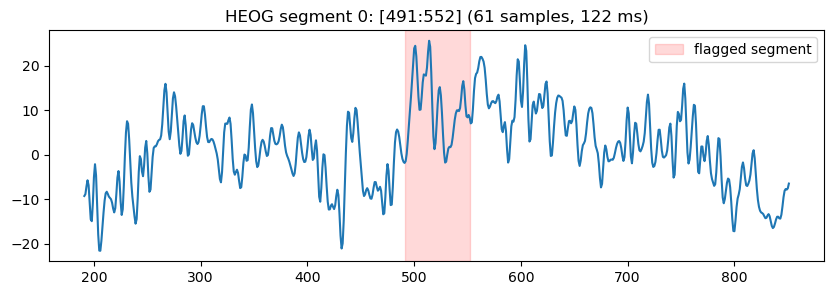

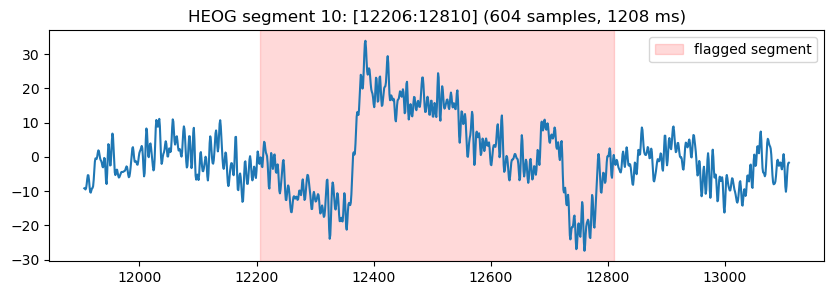

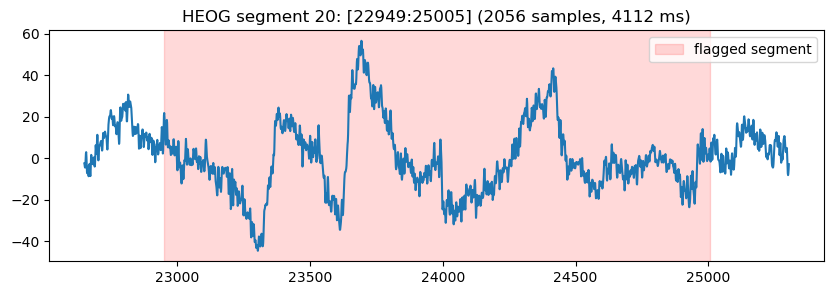

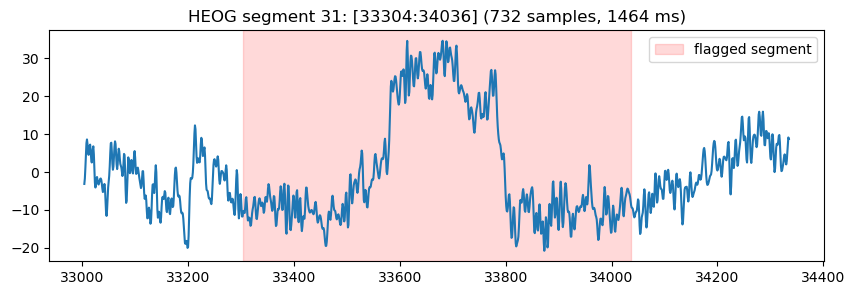

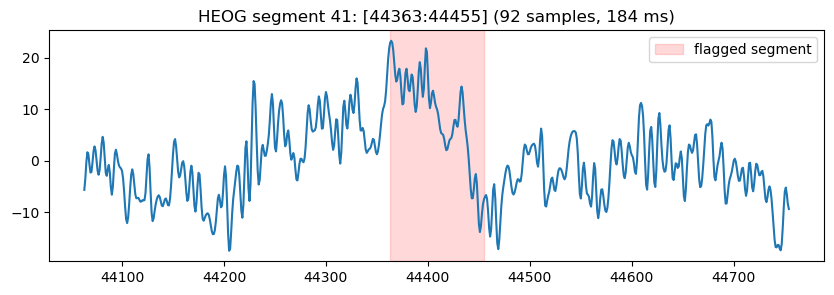

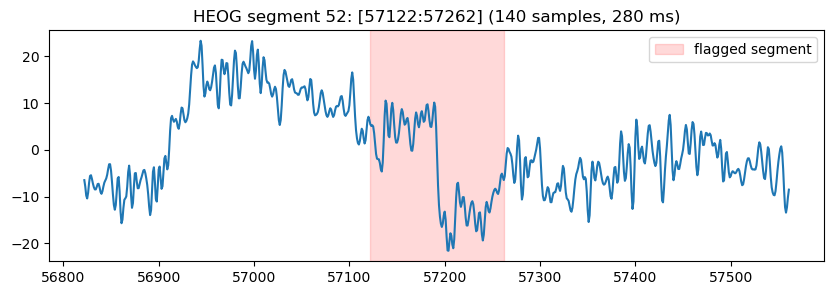

In [26]:
raw = load_and_prepare_raw('sub-88047245', 'restEC', data_dir)
raw = bipolarEOG(raw)
raw = demean(raw)
raw = apply_filters(raw)

heog_data = raw.get_data(picks=['HEOG'])[0]
Fs = raw.info['sfreq']
segs = detect_artefact_segments(heog_data, Fs)
valid_amp, _ = amplitude_guard(heog_data, segs, threshold=1000)
valid_dur, _ = duration_guard(valid_amp, Fs, blink_duration_threshold=100)

print(f"{len(valid_dur)} valid segments")

heog_1e6 = heog_data * 1e6

import matplotlib.pyplot as plt

# Sample a handful spread across the recording, not just the first few
sample_idx = np.linspace(0, len(valid_dur) - 1, 6, dtype=int)

for i in sample_idx:
    start, end = valid_dur[i]
    margin = 300
    window = slice(max(0, start - margin), min(len(heog_1e6), end + margin))
    x = range(window.start, window.stop)
    plt.figure(figsize=(10, 3))
    plt.plot(x, heog_1e6[window])
    plt.axvspan(start, end, color='red', alpha=0.15, label='flagged segment')
    plt.title(f'HEOG segment {i}: [{start}:{end}] ({end-start} samples, {(end-start)/Fs*1000:.0f} ms)')
    plt.legend()
    plt.show()

## Finding: HEOG "valid" segments are largely non-saccadic drift, not artefacts to correct

**What was found**: the batch HEOG segment counts (30-86 candidates per subject, 6/6 batch
subjects) are far higher than the pilot subject's 2-8, initially raising the question of
whether the pilot subject was an atypically clean outlier. A visual check on 6 sampled "valid"
segments from `sub-88047245` (restEC) found segment durations ranging from 92 ms to 4,112 ms -
several multiples longer than any genuine saccade. Baseline HEOG in all six plots showed
continuous background oscillation both inside and outside flagged regions, unlike VEOG's
visibly quiet baseline outside genuine blinks (see earlier VEOG validation).

**Literature check**: saccades are ballistic movements typically lasting 30-120 ms
(Sheena & Borah, patent US5726916, "Method and apparatus for determining ocular gaze point
of regard and fixation duration"), with mean durations around 36-37 ms reported in a
conjunctive visual search task (SD ~14 ms; Resca, L., Greenwood, P. M., & Keech, T. D., 2013,
in *Eye Movement*, ed. L. C. Stewart, Nova Science Publishers, ISBN 978-1-62808-601-0).
Bögels & Kayser (2022, *Journal of Neurophysiology*,
https://doi.org/10.1152/jn.00076.2022) explicitly note that saccades and baseline EOG drift
occupy different timescales and are recognised as distinct phenomena, not points on the same
continuum. None of this is consistent with a 604-4,112 ms "segment" being a genuine saccade.

**Conclusion**: `duration_guard` currently enforces only a *minimum* duration (100 ms) with
no maximum, so slow drift periods - which the detection method's z-threshold also flags,
since drift is a sustained deviation from baseline the same way a saccade is - pass through
unfiltered as "valid." The pilot subject was not an atypical outlier; the detection/guard
chain as currently built over-flags HEOG broadly, and the pilot subject's low candidate count
(and near-total exclusion via the amplitude guard) masked this gap rather than avoiding it.

**Fix**: add a maximum-duration bound to `duration_guard`, informed by the literature range
above (conservatively ~150-200 ms, generous relative to the documented 30-120 ms saccade
range) - see next section.

In [27]:
#Verification of duration guard update
raw = load_and_prepare_raw('sub-88047245', 'restEC', data_dir)
raw = bipolarEOG(raw)
raw = demean(raw)
raw = apply_filters(raw)

heog_data = raw.get_data(picks=['HEOG'])[0]
Fs = raw.info['sfreq']
segs = detect_artefact_segments(heog_data, Fs)
valid_amp, _ = amplitude_guard(heog_data, segs, threshold=1000)

# Without max duration (original behavior)
valid_dur_old, excluded_old = duration_guard(valid_amp, Fs, blink_duration_threshold=100)

# With max duration
valid_dur_new, excluded_new = duration_guard(valid_amp, Fs, blink_duration_threshold=100,
                                               max_duration_threshold=200)

print(f"Without max: {len(valid_dur_old)} valid")
print(f"With max=200ms: {len(valid_dur_new)} valid")
print()
print("Durations of segments now excluded by the max bound:")
newly_excluded = set(map(tuple, valid_dur_old)) - set(map(tuple, valid_dur_new))
for start, end in sorted(newly_excluded):
    print(f"  [{start}:{end}] - {(end-start)/Fs*1000:.0f} ms")

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-88047245/ses-1/eeg/sub-88047245_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.
Without max: 53 valid
With max=200ms: 7 valid

Durations of segments now excluded by the max bound:
  [777:1451] - 1348 ms
  [1498:1708] - 420 ms
  [3532:3891] - 718 ms
  [7120:7280] - 320 ms
  [7826:7941] - 230 ms
  [8006:8162] - 312 ms
  [10016:11945] - 3858 ms
  [12206:12810] - 1208 ms
  [13345:13591] - 492 ms
  [14353:14460] - 214 ms
  [14690:15671] - 1962 ms
  [16188:16606] - 836 ms
  [16972:17335] - 726 ms
  [19281:20361] - 2160 ms
  [20804:21349] - 1090 ms
  [22564:22948] - 768 ms
  [22949:25005] - 4112 ms
  [26596:26759] - 326 ms
  [26790:27073] - 566 ms
  [27359:2

In [28]:
# Check the 7 survivors actual durations
for start, end in valid_dur_new:
    print(f"[{start}:{end}] - {(end-start)/Fs*1000:.0f} ms")

[491:552] - 122 ms
[7549:7647] - 196 ms
[9576:9667] - 182 ms
[14527:14614] - 174 ms
[25094:25166] - 144 ms
[44363:44455] - 184 ms
[56051:56118] - 134 ms


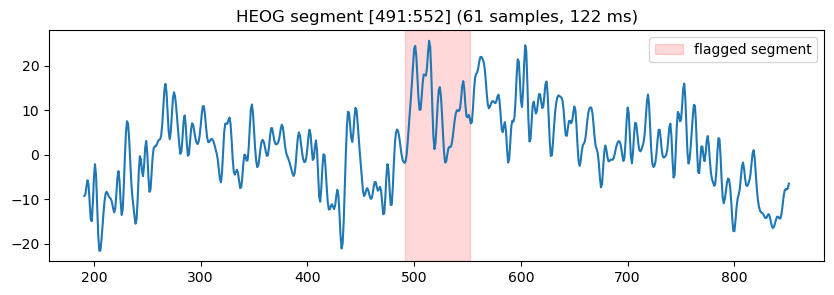

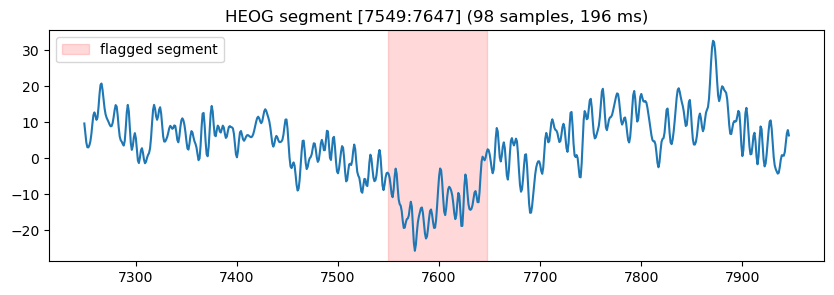

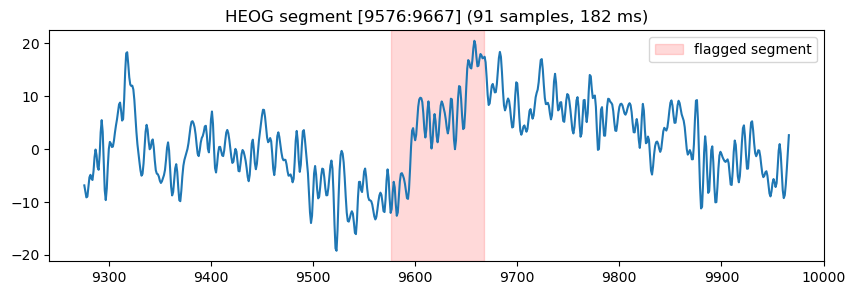

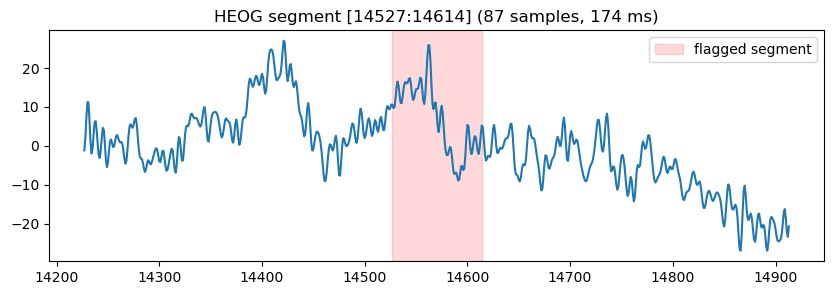

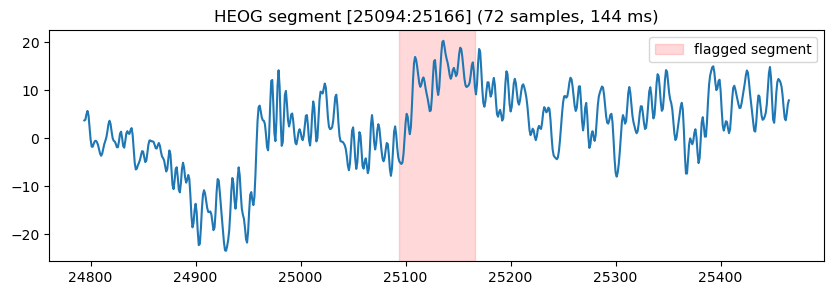

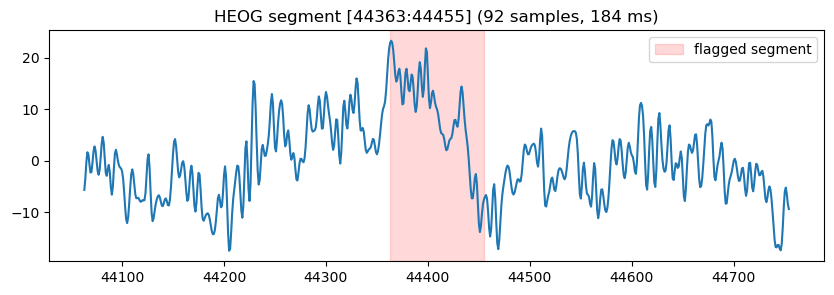

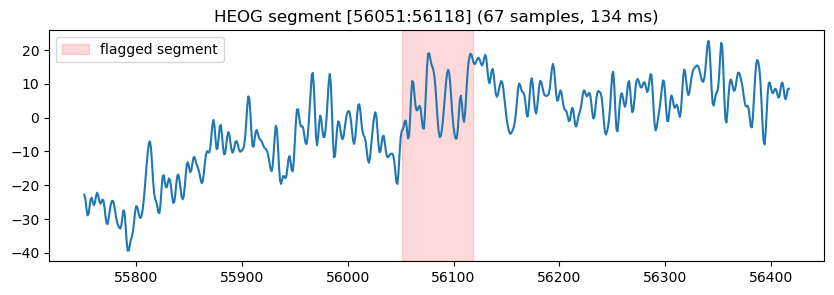

In [29]:
for (start, end) in valid_dur_new:
    margin = 300
    window = slice(max(0, start - margin), min(len(heog_data), end + margin))
    x = range(window.start, window.stop)
    heog_1e6 = heog_data * 1e6
    plt.figure(figsize=(10, 3))
    plt.plot(x, heog_1e6[window])
    plt.axvspan(start, end, color='red', alpha=0.15, label='flagged segment')
    plt.title(f'HEOG segment [{start}:{end}] ({end-start} samples, {(end-start)/Fs*1000:.0f} ms)')
    plt.legend()
    plt.show()

## Conclusion: HEOG duration fix - real improvement, not full resolution

**Fix impact confirmed**: `max_duration_threshold=200` reduced `sub-88047245` restEC's valid
HEOG segments from 53 to 7, removing all segments with durations exceeding the literature-
grounded saccade range (30-120 ms; see finding above). This is a genuine, evidence-backed
improvement - the pre-fix candidate pool was dominated by multi-second drift periods that
could not plausibly be saccades.

**Visual check of the 7 survivors (122-196 ms) - result is mixed, not confirmatory**: unlike
the VEOG validation earlier in this project (clean, isolated blinks rising from and returning
to a visibly quiet baseline), most of these HEOG segments do not show that signature. Two show
a step-shift to a new baseline level rather than a return to rest ([7549:7647],
[9576:9667]); one sits inside a continuous trend with no distinct feature at the flagged
region ([56051:56118]); the remainder show a rise-and-fall shape but against a
baseline that is already actively fluctuating, unlike VEOG's quiet baseline. Only
[25094:25166] and [44363:44455] look reasonably close to plausible saccades.

**Two possible explanations, not distinguished by this evidence**:
1. Remaining segments are still partly spurious - shorter-duration noise/drift that happens
   to fall under the 200 ms bound rather than genuine saccades.
2. HEOG's baseline is inherently noisier than VEOG's by nature (continuous small eye-position
   adjustments vs. VEOG's discrete, punctate blinks), so a VEOG-quality quiet baseline may not
   be a realistic bar for HEOG at all.

**Status**: the duration fix is retained as a real improvement and applied to HEOG detection.
HEOG-based correction should be treated as lower-confidence than VEOG-based correction until
this is resolved - not presented as fully validated to the same standard. Open item, not
closed.